In [7]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

In [9]:
import pandas as pd
data=pd.read_csv('wine.csv')
y=data['quality']
X=data.drop(['quality'],axis=1)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.25,
                                               random_state=42)


In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1199, 11)
(1199,)
(400, 11)
(400,)


In [12]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(32,input_shape = (11,),activation = 'relu'))
model.add(Dense(6,activation='softmax'))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
y_train = y_train - 3
y_test = y_test - 3
print(np.unique(y_train))

[0 1 2 3 4 5]


d:\Coding_here\PythonLearningsOnly\InternshipProgram3rdYear\PythonProgram\env313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.fit(X_train,
          y_train,
          epochs=100,
          batch_size=32,
          validation_data=(X_test,y_test))

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3186 - loss: 1.6257 - val_accuracy: 0.4000 - val_loss: 1.4760
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4987 - loss: 1.3479 - val_accuracy: 0.4775 - val_loss: 1.2815
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5571 - loss: 1.2009 - val_accuracy: 0.5100 - val_loss: 1.1826
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5630 - loss: 1.1220 - val_accuracy: 0.5225 - val_loss: 1.1302
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5788 - loss: 1.0776 - val_accuracy: 0.5325 - val_loss: 1.0979
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5847 - loss: 1.0503 - val_accuracy: 0.5450 - val_loss: 1.0767
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5905 - loss: 1.0314 - val_accuracy: 0.5525 - val_loss: 1.0579
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6013 - loss: 1.0160 - val_accuracy: 0.5575 - v

In [14]:
model.save("wine_model.h5")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [15]:
pred = model.predict(x_test)
pred = np.argmax(pred,axis = 1)
pred = pred + 3
print(pred)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[5 5 5 5 5 5 5 7 5 5 7 6 5 5 5 7 5 5 7 5 7 5 7 7 6 5 5 5 5 5 5 5 5 6 5 5 7
 7 5 7 5 5 7 5 7 7 6 5 5 6 5 5 7 5 5 5 7 5 5 5 5 7 5 5 7 5 7 5 6 5 5 5 5 5
 7 5 5 5 5 5 5 7 5 7 5 5 5 7 5 6 5 5 6 7 5 7 5 7 7 5 7 5 5 7 5 5 7 5 5 5 5
 5 5 5 7 7 6 5 5 5 5 5 5 5 6 5 5 5 5 5 5 6 5 7 6 5 5 5 5 5 5 5 7 6 7 5 6 6
 5 5 5 7 5 5 5 5 5 5 5 7 7 5 5 5 5 5 5 5 5 5 5 6 7 5 5 5 5 5 5 5 7 5 5 7 7
 5 7 5 7 5 5 5 5 5 5 5 5 5 5 5 7 5 5 5 5 5 5 5 5 5 5 5 6 5 7 6 5 5 5 5 5 5
 5 5 5 5 5 7 5 5 5 5 7 7 7 5 7 5 7 5 7 5 5 6 5 5 7 5 7 5 5 6 7 5 7 5 5 7 7
 5 5 6 5 7 6 7 5 5 5 5 5 5 5 5 5 5 5 5 5 5 7 6 5 5 5 5 5 5 5 5 5 7 7 5 5 5
 5 7 5 6 5 5 5 5 5 5 5 5 7 7 5 5 5 6 6 5 5 5 7 6 5 5 7 7 5 5 5 5 5 5 7 7 5
 5 7 5 5 5 5 5 5 7 6 5 5 5 7 7 5 7 7 7 6 5 5 5 6 7 5 5 7 5 7 5 5 5 5 5 5 5
 5 6 5 6 5 7 5 7 5 5 5 7 5 5 5 5 5 5 5 5 7 5 7 5 5 5 7 5 6 6]


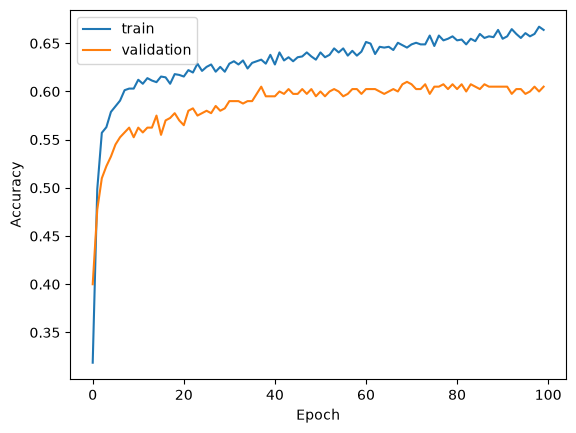

In [16]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['accuracy'],label = 'train')
plt.plot(model.history.history['val_accuracy'],label = 'validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

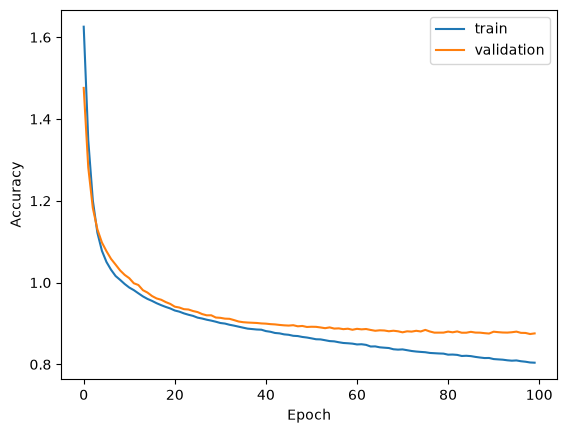

In [17]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'],label = 'train')
plt.plot(model.history.history['val_loss'],label = 'validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()